Importing important library

In [2]:
!pip install pandas_ta

Using legacy 'setup.py install' for pandas-ta, since package 'wheel' is not installed.
    Running setup.py install for pandas-ta: started
    Running setup.py install for pandas-ta: finished with status 'done'


You should consider upgrading via the 'c:\users\amit.ranjan\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [8]:
data = yf.download('SBIN.NS', period='5y')
data.tail()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-14,845.000000,849.900024,835.099976,839.200012,839.200012,12903496
2024-06-18,841.549988,851.500000,840.250000,844.900024,844.900024,14929083
2024-06-19,846.799988,860.599976,841.000000,852.599976,852.599976,32925140
2024-06-20,853.000000,853.099976,842.349976,843.750000,843.750000,13985352
2024-06-21,844.900024,848.049988,828.599976,836.299988,836.299988,18984546


pandas_ta.pvi: This function calculates the Positive Volume Index (PVI). The Positive Volume Index is a cumulative indicator that increases when the volume is higher than the previous day's volume and remains unchanged when the volume is lower.

length=20: This parameter specifies the lookback period or the window length used in the calculation of the PVI. In this case, it is set to 20 periods (typically 20 days for daily data).

In [9]:
data['PVI'] = pandas_ta.pvi(close=data['Adj Close'],volume = data['Volume'],length=20)

In [10]:
data['RSI'] = pandas_ta.rsi(close=data['Adj Close'], length=20)

In [11]:
data['RSI_lag'] = data['RSI'].shift()

In [12]:
data= data.dropna()

In [13]:
data.head()

,Open,High,Low,Close,Adj Close,Volume,PVI,RSI,RSI_lag
Date,,,,,,,,,
2019-07-22,356.000000,359.549988,348.700012,350.850006,330.235596,19682038,1001.888954,44.936877,48.760339
2019-07-23,351.200012,353.000000,341.000000,342.200012,322.093811,27956145,997.864279,39.465532,44.936877
2019-07-24,341.850006,344.700012,336.250000,339.600006,319.646576,20823143,997.864279,38.001585,39.465532
2019-07-25,341.700012,343.200012,337.399994,341.299988,321.246643,19857643,997.864279,39.544986,38.001585
2019-07-26,340.799988,346.149994,340.500000,342.600006,322.470337,16139052,997.864279,40.732733,39.544986


In [15]:
data['Signal_1'] = data['PVI'].diff().apply(lambda x:1 if x>1 else(-1 if x<1 else np.nan))

data['Signal_2'] = data.apply(lambda x: 1 if (x['RSI_lag']<50) & (x['RSI']>50) 
                              else (-1 if (x['RSI_lag']>50) & (x['RSI']<50) else np.nan), axis=1)

In [16]:
data.head()

,Open,High,Low,Close,Adj Close,Volume,PVI,RSI,RSI_lag,Signal_1,Signal_2
Date,,,,,,,,,,,
2019-07-22,356.000000,359.549988,348.700012,350.850006,330.235596,19682038,1001.888954,44.936877,48.760339,NaN,NaN
2019-07-23,351.200012,353.000000,341.000000,342.200012,322.093811,27956145,997.864279,39.465532,44.936877,-1.0,NaN
2019-07-24,341.850006,344.700012,336.250000,339.600006,319.646576,20823143,997.864279,38.001585,39.465532,-1.0,NaN
2019-07-25,341.700012,343.200012,337.399994,341.299988,321.246643,19857643,997.864279,39.544986,38.001585,-1.0,NaN
2019-07-26,340.799988,346.149994,340.500000,342.600006,322.470337,16139052,997.864279,40.732733,39.544986,-1.0,NaN


In [29]:
data['Position'] = data.apply(lambda x:'Buy' if (x['Signal_1'] + x['Signal_2']==2)
                              else 'Sell' if (x['Signal_1'] + x['Signal_2']==-2) else np.nan, axis=1)


In [32]:
data['Position_v2'] = data['Position'].shift()

In [18]:
data2 = data[data['Position'].notna()]

In [ ]:
data2['Position_v2'] = data2['Position'].shift()
data2

In [38]:
data2['Position_Final'] = data2.apply(lambda x: 'Buy' if (x['Position'] == 'Buy' and x['Position_v2'] != 'Buy')
                                      else 'Sell' if (x['Position'] == 'Sell' and x['Position_v2'] != 'Sell') else np.nan, axis=1)

In [40]:
data3 = data2[data2['Position_Final'].notna()]

In [48]:
data3.head()

,Open,High,Low,Close,Adj Close,Volume,PVI,RSI,RSI_lag,Signal_1,Signal_2,Position,Position_v2,Position_Final
Date,,,,,,,,,,,,,,
2019-09-20,274.500000,307.649994,268.399994,301.700012,283.973450,84481749,743.131015,52.590372,39.323552,1.0,1.0,Buy,None,Buy
2019-09-25,297.000000,297.500000,278.700012,280.250000,263.783752,73063465,743.148858,44.597264,52.271025,-1.0,-1.0,Sell,Buy,Sell
2020-02-19,322.299988,324.000000,317.250000,320.350006,301.527649,39846727,865.208914,50.319104,48.921295,1.0,1.0,Buy,Sell,Buy
2020-02-28,312.000000,314.649994,301.100006,303.000000,285.197021,59705346,869.663490,42.105136,50.487083,-1.0,-1.0,Sell,Buy,Sell
2020-06-05,176.550003,189.800003,176.000000,187.800003,176.765701,201321234,350.953256,54.647648,47.045803,1.0,1.0,Buy,Sell,Buy


In [56]:
def strategy_implementation(data, investment):
    equity = investment  
    pos = 0 #initially we do not hold any position
    buy=[]
    sell = []

    for i in range(len(data['Position_Final'])):
        if data['Position_Final'][i] == 'Sell':
            sell.append(1)
            pos -= 1
            equity += data['Adj Close'][i]
            print(f"SELL at price {data['Adj Close'][i]:.2f}. Equity: {equity:.2f}.")

        elif data['Position_Final'][i] == 'Buy':
            buy.append(1)
            pos += 1
            equity -= data['Adj Close'][i]
            print(f"BUY at price {data['Adj Close'][i]:.2f}. Equity: {equity:.2f}.")

        #Make sure no positions held at the end of the period

        if pos>1:
            stocks_sold = pos
            equity += stocks_sold * data['Adj Close'][i]
            print(f"SELL at price {data['Adj Close'][i]:.2f}. Equity: {equity:.2f}. Stocks sold to close existing position {stocks_sold}.")
            sell.append(1)
        elif pos<1:
            stocks_bought = abs(pos)
            equity -= stocks_bought * data['Adj Close'][i]
            print(f"BUY at price {data['Adj Close'][i]:.2f}. Stocks bought to close existing position {stocks_bought}.")
            buy.append(1)

        print('')
        print(f"Number of Trades {len(buy)+len(sell)}.")
        print(f"Number of Buy trades {len(buy)}.")
        print(f"Number of Sell trades {len(sell)}.")



In [58]:
strategy_implementation(data3,100000)

BUY at price 283.97. Equity: 99716.03.

Number of Trades 1.
Number of Buy trades 1.
Number of Sell trades 0.
SELL at price 263.78. Equity: 99979.81.
BUY at price 263.78. Stocks bought to close existing position 0.

Number of Trades 3.
Number of Buy trades 2.
Number of Sell trades 1.
BUY at price 301.53. Equity: 99678.28.

Number of Trades 4.
Number of Buy trades 3.
Number of Sell trades 1.
SELL at price 285.20. Equity: 99963.48.
BUY at price 285.20. Stocks bought to close existing position 0.

Number of Trades 6.
Number of Buy trades 4.
Number of Sell trades 2.
BUY at price 176.77. Equity: 99786.71.

Number of Trades 7.
Number of Buy trades 5.
Number of Sell trades 2.
SELL at price 173.00. Equity: 99959.71.
BUY at price 173.00. Stocks bought to close existing position 0.

Number of Trades 9.
Number of Buy trades 6.
Number of Sell trades 3.
BUY at price 180.20. Equity: 99779.51.

Number of Trades 10.
Number of Buy trades 7.
Number of Sell trades 3.
SELL at price 183.40. Equity: 99962.91

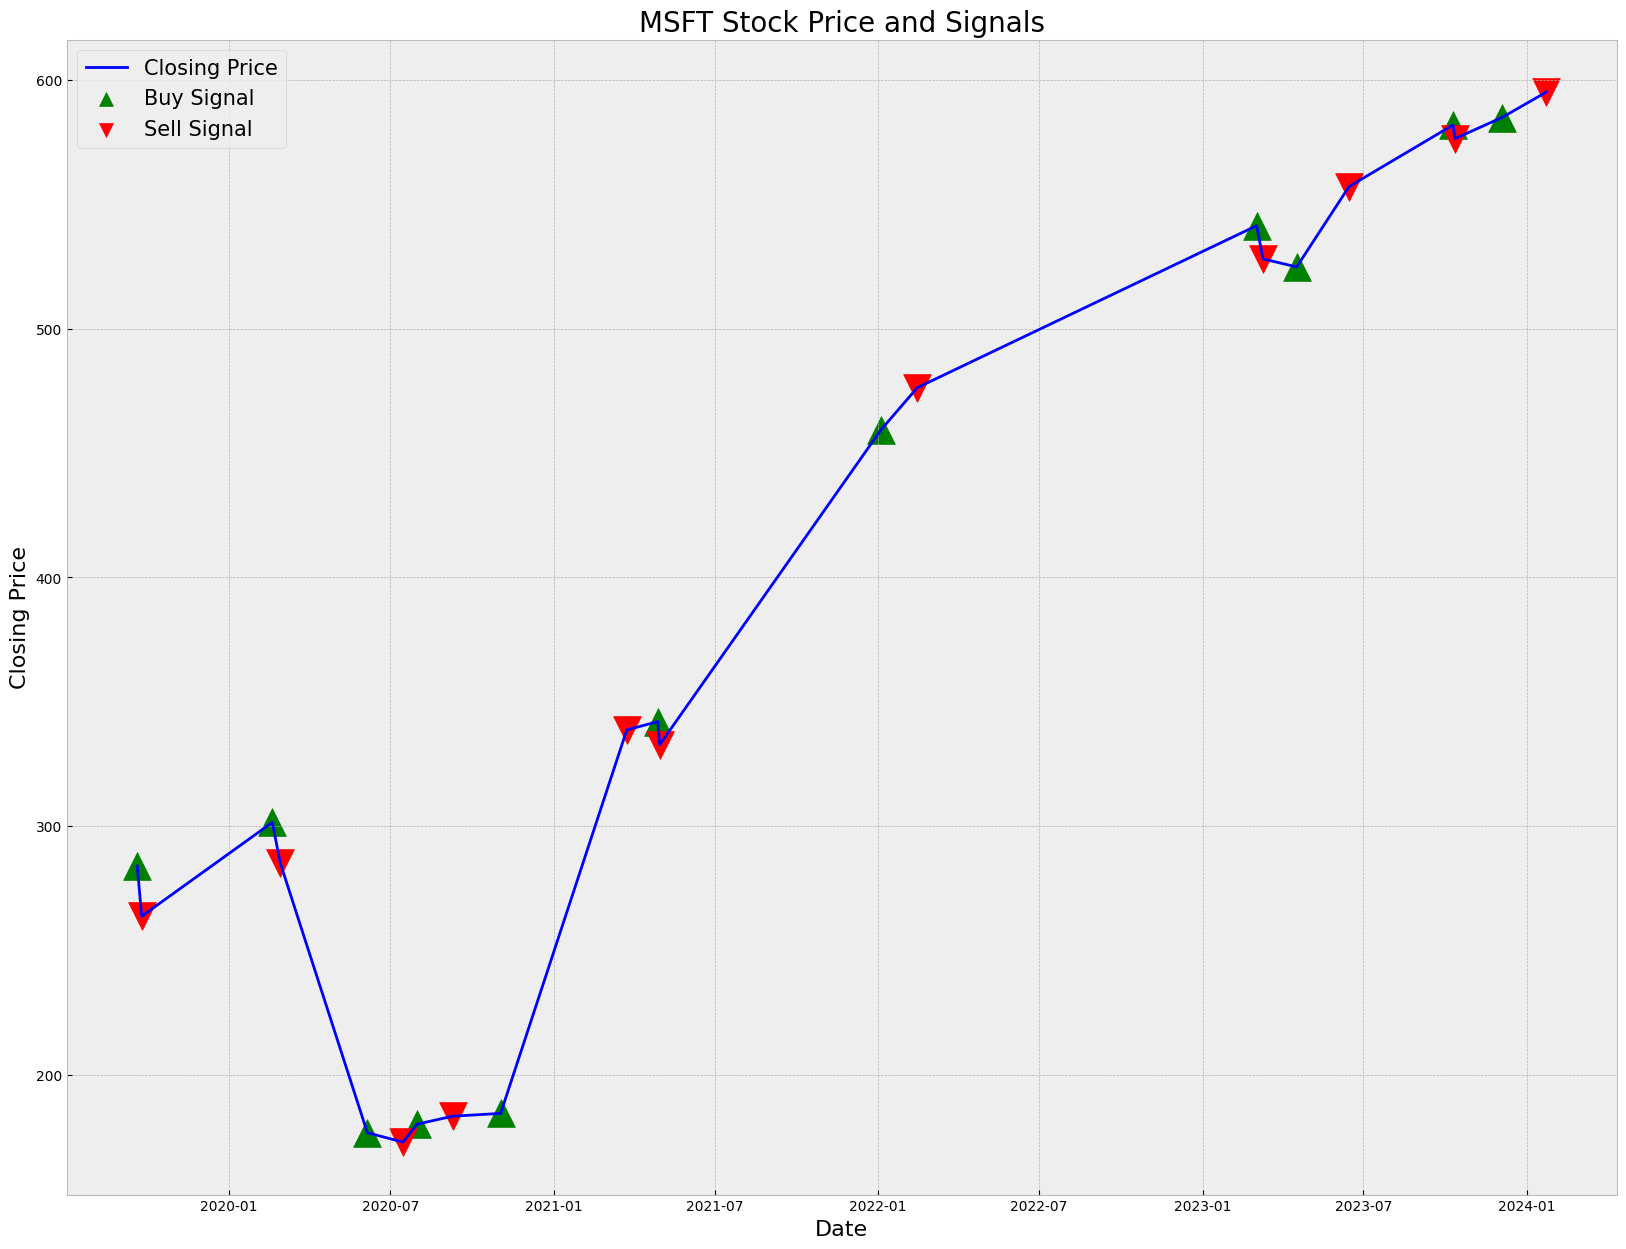

In [59]:
plt.figure(figsize=(20,15))
plt.style.use("bmh")
plt.plot(data3['Adj Close'], label='Closing Price', linestyle="-", linewidth=2,color='blue')
buy = data3[data3['Position']=='Buy']['Adj Close']
plt.scatter(buy.index, buy, marker="^", color='g', s=400, label='Buy Signal')
sell = data3[data3['Position']=='Sell']['Adj Close']
plt.scatter(sell.index, sell, marker="v", color='r', s=400, label='Sell Signal')
plt.title("MSFT Stock Price and Signals", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Closing Price", fontsize=16)
plt.legend(loc='upper left', markerscale=0.5,fontsize=15)
plt.show()